In [1]:
from pathlib import Path
from torchvision.datasets import ImageFolder
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.amp import GradScaler, autocast

In [2]:
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.enabled = True
torch.cuda.empty_cache()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ROOT = Path(r"D:/assignment_dataset")

IMAGE_ROOT = ROOT / "images"
LABEL_ROOT = ROOT / "labels"

TRAIN_LABELS = LABEL_ROOT / "train.txt"
VALID_LABELS = LABEL_ROOT / "val.txt"
TEST_LABELS = LABEL_ROOT / "test.txt"

BATCH_SIZE = 64
NUM_WORKERS = 8

Total_epochs = 20

In [3]:
train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomRotation(3),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.03,0.03)
    ),
    transforms.ColorJitter(
        brightness=0.05,
        contrast=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

valid_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [4]:
train_dataset = ImageFolder(
    root=r"D:\assignment_dataset\df\train",
    transform=train_transforms
)

valid_dataset = ImageFolder(
    root=r"D:\assignment_dataset\df\valid",
    transform=valid_test_transforms
)

test_dataset = ImageFolder(
    root=r"D:\assignment_dataset\df\test",
    transform=valid_test_transforms
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

print("Train:", len(train_dataset))
print("Valid:", len(valid_dataset))
print("Test :", len(test_dataset))

Train: 319837
Valid: 39995
Test : 39996


In [5]:
model = models.resnet50(weights='ResNet50_Weights.DEFAULT')
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, 16)  # Multi-Class classification
model = model.to(device)

In [6]:
# Stage 1: Gradual Unfreezing with LLRD (training the classifier + final residual block layers in the network)    
layer_wise_lr = {
    "fc": 1e-3                # Highest learning rate for classification head
}
layer4_params = []
fc_params = []

for name, param in model.named_parameters():
        
    # Fully Connected Layer (Classifier layer)
    if 'fc.' in name:
        param.requires_grad = True
        fc_params.append(param)
    
    # Final residual block (Task specific features)    
    elif 'layer4.' in name:

        param.requires_grad = False
        layer4_params.append(param)
    
    # Freeze early and middle residual blocks
    else:
        param.requires_grad = False

In [7]:
criterion = nn.CrossEntropyLoss(label_smoothing = 0.05)

def train_model(model, train_loader, valid_loader, optimizer, scheduler, num_epochs, stage="Training Stage"):    
    train_losses = []
    val_losses=[]
    train_accuracies = []
    val_accuracies = []
    scaler = GradScaler("cuda")

    best_val_loss = float("inf")
    early_stop_count = 0
    patience = 5

    for epoch in range(num_epochs):
        if epoch == 5:

            print("\nUnfreezing Layer4...\n")

            for param in layer4_params:
                param.requires_grad = True

            optimizer.add_param_group(
                {
                    'params': layer4_params,
                    'lr': 1e-4
                }
            )
        total_train_loss, total_correct, total_samples = 0.0, 0, 0
        model.train()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            with autocast(device_type = 'cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_train_loss += loss.item() * images.size(0)
            total_correct += (outputs.argmax(1) == labels).sum().item()
            total_samples += labels.size(0)

        train_loss = total_train_loss / total_samples
        train_acc = total_correct / total_samples
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        model.eval()
        total_val_loss, total_val_correct, total_val_samples = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in valid_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                total_val_loss += loss.item() * images.size(0)
                total_val_correct += (outputs.argmax(1) == labels).sum().item()
                total_val_samples += labels.size(0)
                
        val_loss = total_val_loss / total_val_samples
        val_acc = total_val_correct / total_val_samples
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        print(f"[{stage}] Epoch {epoch+1}/{num_epochs}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")


        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stop_count = 0
            torch.save(model.state_dict(), "best_res50.pth")
        else:
            early_stop_count += 1
            if early_stop_count >= patience:
                print("Early stopping triggered.")
                break
        scheduler.step()
    plt.figure(figsize=(12, 8))
    plt.plot(train_losses, label="Training Loss",color = 'red')
    plt.plot(val_losses, label="Validation Loss",color = 'blue')
    plt.xlabel("No of Epochs")
    plt.ylabel("Loss")
    plt.title("Loss per epoch")
    plt.legend()
    plt.show()
    
    plt.figure(figsize=(12, 8))
    plt.plot(train_accuracies, label="Training Accuracy",color = 'red')
    plt.plot(val_accuracies, label="Validation Accuracy",color = 'blue')
    plt.xlabel("No of Epochs")
    plt.ylabel("Accuracy")
    plt.title("Accuracy per epoch")
    plt.legend()
    plt.show()

In [8]:
# Print all model parameter names for easier debugging
# for name, _ in model.named_parameters():
#     print(name)

Created 1 parameter groups for optimizer
[Training stage] Epoch 1/20: Train Loss: 1.5290, Train Acc: 0.5937 | Val Loss: 1.3904, Val Acc: 0.6388
[Training stage] Epoch 2/20: Train Loss: 1.4182, Train Acc: 0.6291 | Val Loss: 1.3665, Val Acc: 0.6471
[Training stage] Epoch 3/20: Train Loss: 1.4085, Train Acc: 0.6325 | Val Loss: 1.3638, Val Acc: 0.6483
[Training stage] Epoch 4/20: Train Loss: 1.4015, Train Acc: 0.6341 | Val Loss: 1.3590, Val Acc: 0.6496
[Training stage] Epoch 5/20: Train Loss: 1.4007, Train Acc: 0.6358 | Val Loss: 1.3492, Val Acc: 0.6530

Unfreezing Layer4...

[Training stage] Epoch 6/20: Train Loss: 1.0032, Train Acc: 0.7762 | Val Loss: 0.8240, Val Acc: 0.8384
[Training stage] Epoch 7/20: Train Loss: 0.7893, Train Acc: 0.8491 | Val Loss: 0.7472, Val Acc: 0.8635
[Training stage] Epoch 8/20: Train Loss: 0.7137, Train Acc: 0.8728 | Val Loss: 0.7046, Val Acc: 0.8784
[Training stage] Epoch 9/20: Train Loss: 0.6634, Train Acc: 0.8902 | Val Loss: 0.6862, Val Acc: 0.8840
[Training

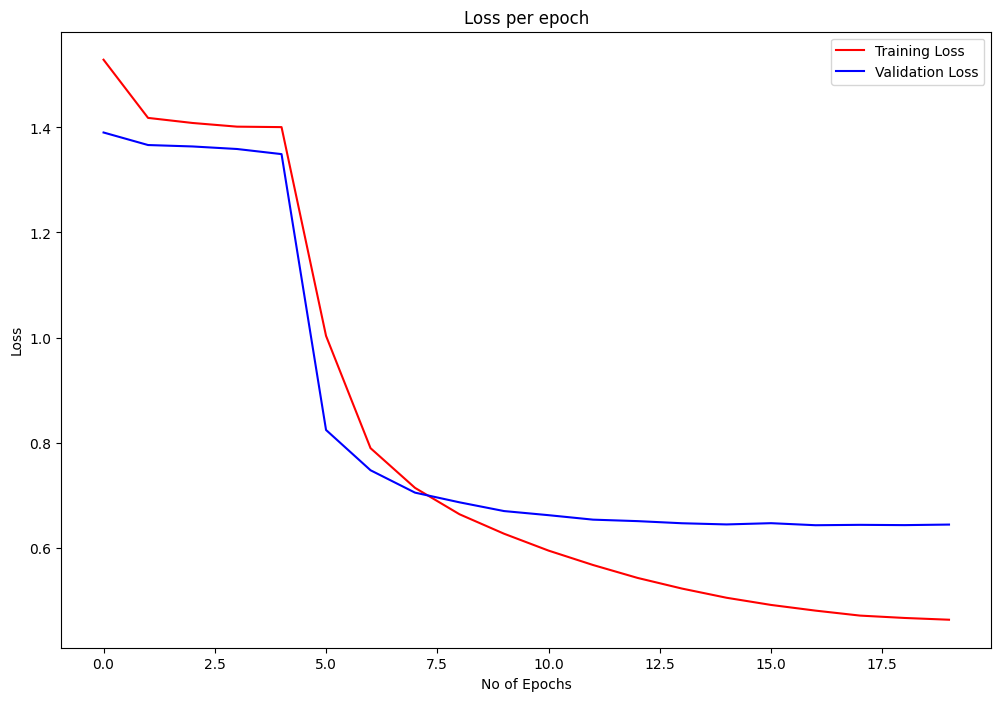

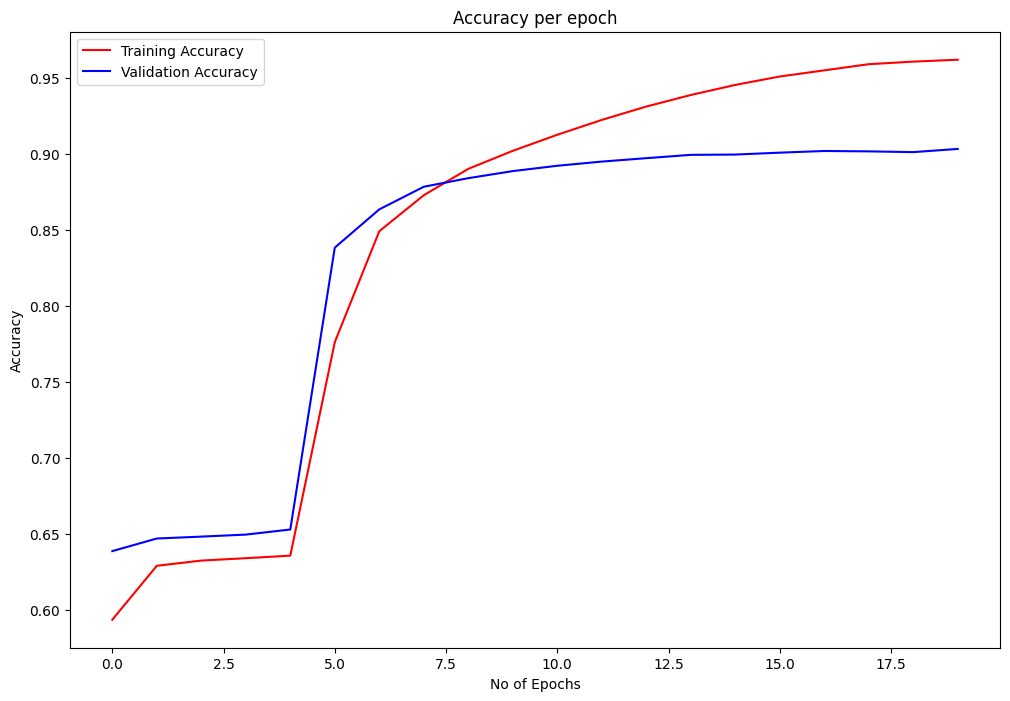

In [9]:
# Training Only the Classifier layer
param_groups = [
    {'params': fc_params, 'lr': layer_wise_lr['fc']}
]
param_groups = [group for group in param_groups if len(group['params'])]
print(f"Created {len(param_groups)} parameter groups for optimizer")

optimizer = optim.AdamW(param_groups, weight_decay = 1e-4)
cosine_scheduler = CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-6)
train_model(model, train_loader, valid_loader, optimizer, cosine_scheduler, Total_epochs, stage="Training stage")

In [10]:
def evaluate_model(model, loader):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            preds = outputs.argmax(dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    return np.array(y_true), np.array(y_pred)

In [11]:
# Perform Validation of model to plot all Validation curves 
model.load_state_dict(torch.load("best_res50.pth"))
model.to(device)
y_true_val, y_pred_val = evaluate_model(model, valid_loader)

In [12]:
class_names = [
    "letter",
    "form",
    "email",
    "handwritten",
    "advertisement",
    "scientific_report",
    "scientific_publication",
    "specification",
    "file_folder",
    "news_article",
    "budget",
    "invoice",
    "presentation",
    "questionnaire",
    "resume",
    "memo"
]

In [ ]:
def results(y_true, y_pred):
    print(
    classification_report(
        y_true,
        y_pred,
        digits=4
        )
    )
    print(f"\nThe accuracy score is:{accuracy_score(y_true, y_pred)}")


    print(f"\nThe precision score is:{precision_score(
        y_true,
        y_pred,
        average='macro'
    )}")

    print(f"\nThe recall score is:{recall_score(
        y_true,
        y_pred,
        average='macro'
    )}")

    print(f"\nThe f1-score score is:{f1_score(
        y_true,
        y_pred,
        average='macro'
    )}")
    
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(12,10))

    sns.heatmap(
        cm,
        annot=True,
        xticklabels=class_names,
        yticklabels=class_names,
        cmap="Blues",
        fmt="d"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")

    plt.show()

              precision    recall  f1-score   support

           0     0.9089    0.9334    0.9210      2522
           1     0.8952    0.8938    0.8945      2485
           2     0.9822    0.9842    0.9832      2530
           3     0.9273    0.9633    0.9450      2451
           4     0.8367    0.7939    0.8147      2537
           5     0.9358    0.9466    0.9412      2434
           6     0.9285    0.9127    0.9205      2576
           7     0.8886    0.8864    0.8875      2430
           8     0.9330    0.9072    0.9199      2533
           9     0.9195    0.9093    0.9144      2526
          10     0.8004    0.8545    0.8266      2468
          11     0.8658    0.8645    0.8652      2516
          12     0.9496    0.9476    0.9486      2424
          13     0.9355    0.9188    0.9270      2524
          14     0.7865    0.7827    0.7846      2508
          15     0.9400    0.9344    0.9372      2531

    accuracy                         0.9019     39995
   macro avg     0.9021   

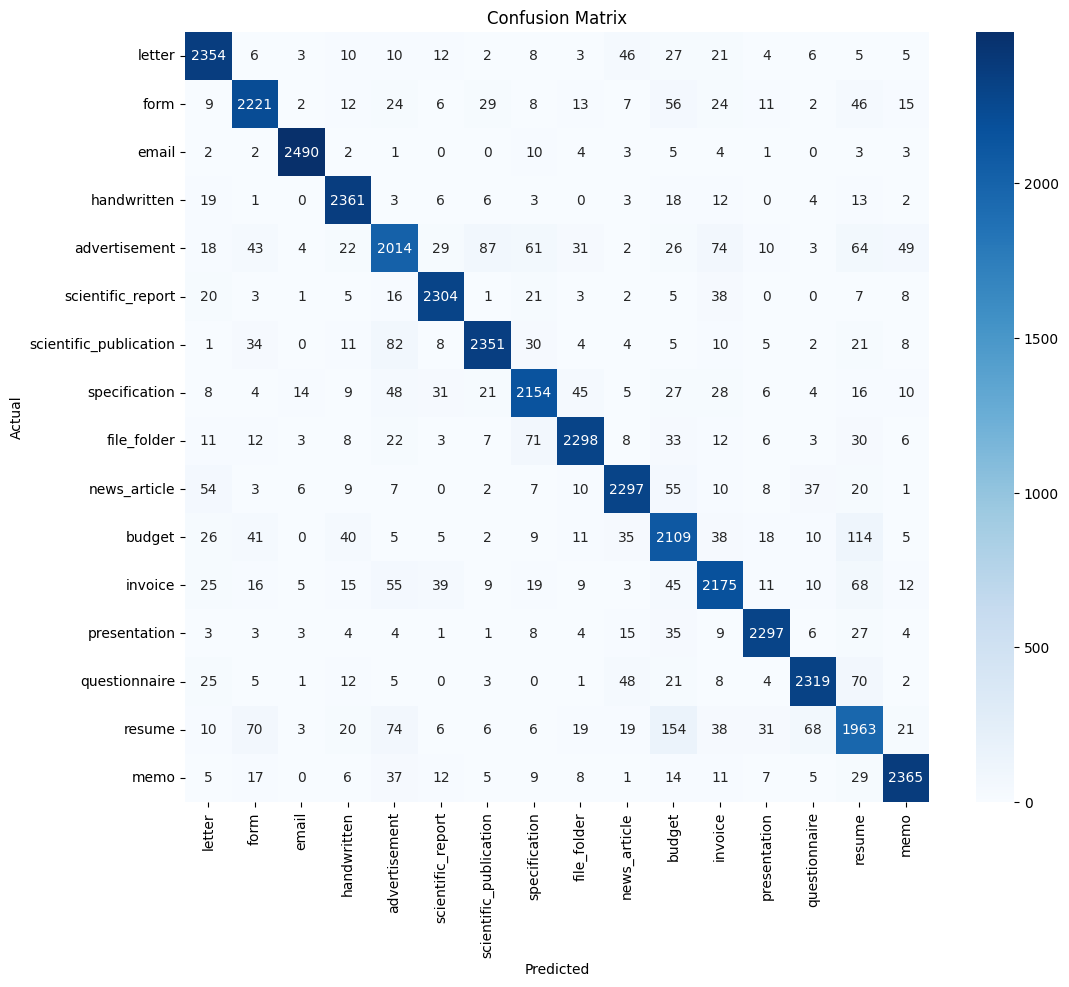

In [14]:
results(y_true_val, y_pred_val)

In [15]:
#Final Testing on test set 
y_true_test, y_pred_test = evaluate_model(model, test_loader)

              precision    recall  f1-score   support

           0     0.9080    0.9340    0.9208      2515
           1     0.8827    0.8834    0.8831      2505
           2     0.9829    0.9817    0.9823      2516
           3     0.9270    0.9652    0.9457      2527
           4     0.8281    0.8113    0.8196      2506
           5     0.9301    0.9506    0.9402      2532
           6     0.9176    0.9080    0.9127      2477
           7     0.8917    0.8754    0.8835      2464
           8     0.9300    0.9169    0.9234      2492
           9     0.9176    0.8993    0.9083      2463
          10     0.8048    0.8381    0.8211      2489
          11     0.8606    0.8620    0.8613      2435
          12     0.9524    0.9550    0.9537      2536
          13     0.9512    0.9183    0.9344      2569
          14     0.7944    0.7902    0.7923      2498
          15     0.9388    0.9248    0.9317      2472

    accuracy                         0.9012     39996
   macro avg     0.9011   

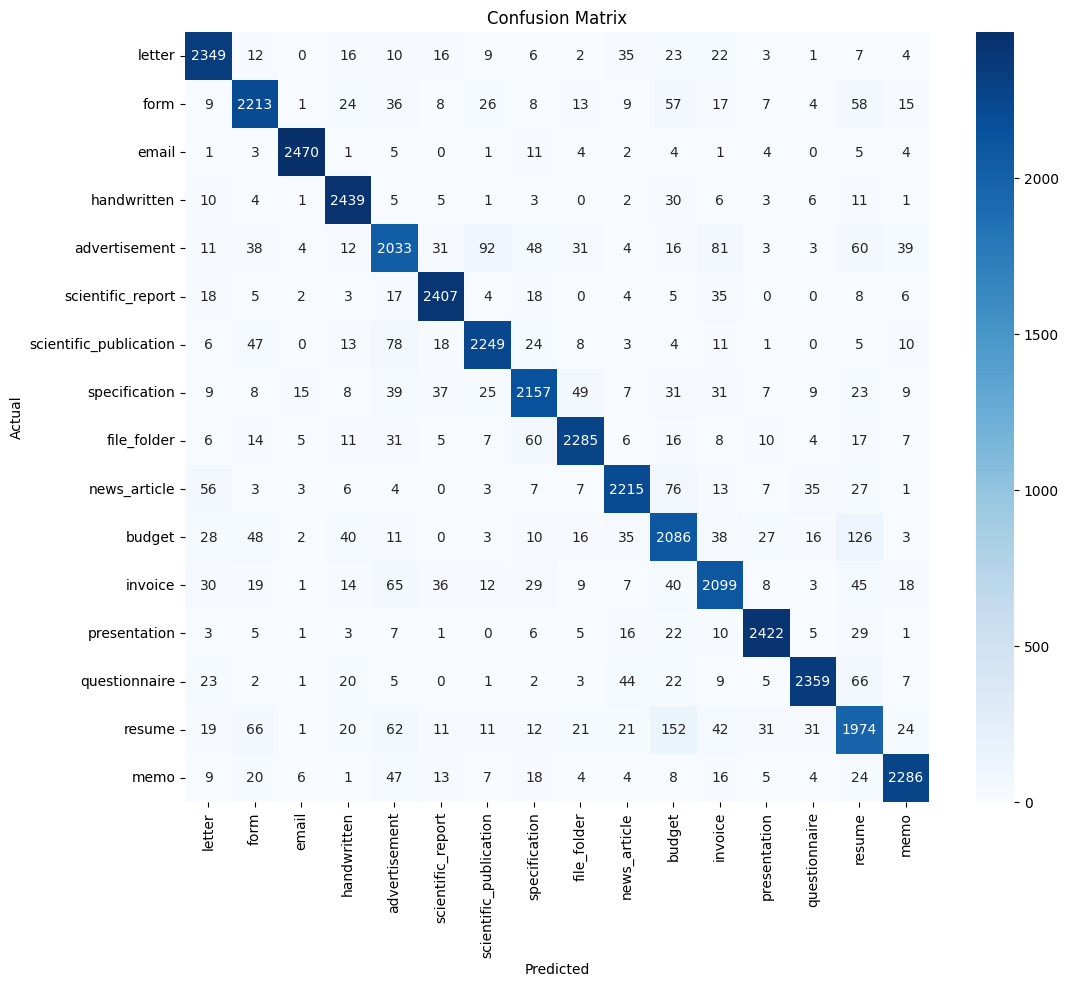

In [16]:
results(y_true_test, y_pred_test)